In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

In [24]:
df =pd.read_excel('/content/Copy of Superstore.xlsx')

In [6]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,2013-06-13,2013-06-17,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [8]:
df.shape

(9994, 21)

In [11]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2013-04-30 19:20:02.401441024,2013-05-04 18:20:49.229537792,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2011-01-04 00:00:00,2011-01-08 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2012-05-23 00:00:00,2012-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2013-06-27 00:00:00,2013-06-30 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2014-05-15 00:00:00,2014-05-19 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2014-12-31 00:00:00,2015-01-06 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


In [17]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [18]:
df.drop_duplicates(inplace=True)

In [20]:
df.shape

(9994, 21)

In [22]:
print(df.dtypes)

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object


In [25]:
df.columns =df.columns.str.lower().str.replace(" ", "_").str.replace("-", "_")

In [26]:
df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub_category',
       'product_name', 'sales', 'quantity', 'discount', 'profit'],
      dtype='object')

In [27]:
#Extrect time feature
df['year'] =df['order_date'].dt.year
df['month'] =df['order_date'].dt.month
df['quarter'] =df['order_date'].dt.quarter
df['month_name'] =df['order_date'].dt.strftime('%b')

In [28]:
#New calculator columns

df['profit_margin'] =(df['profit'] /df['sales']*100).round(2)
df['shipping_days'] =(df['ship_date'] -df['order_date']).dt.days

In [29]:
print('New columns')
print(df[['year','month','quarter','profit_margin','shipping_days']].head())

New columns
   year  month  quarter  profit_margin  shipping_days
0  2013     11        4          16.00              3
1  2013     11        4          30.00              3
2  2013      6        2          47.00              4
3  2012     10        4         -40.00              7
4  2012     10        4          11.25              7


In [30]:
#monthly revenue
monthly =df.groupby(['year','month'])['sales'].sum().reset_index()
#top 10 product
top_products =df.groupby('product_name')['sales'].sum().nlargest(10).reset_index()
#profit by region
region_profit =df.groupby('region')[['sales','profit']].sum().reset_index()
#sales by categories
category =df.groupby(['category','sub_category'])['sales'].sum().reset_index()

print("Monthly sample:\n", monthly.head())
print("\nTop product:", top_products.iloc[0]['product_name'])

Monthly sample:
    year  month      sales
0  2011      1  13946.229
1  2011      2   4810.558
2  2011      3  55691.009
3  2011      4  28295.345
4  2011      5  23648.287

Top product: Canon imageCLASS 2200 Advanced Copier


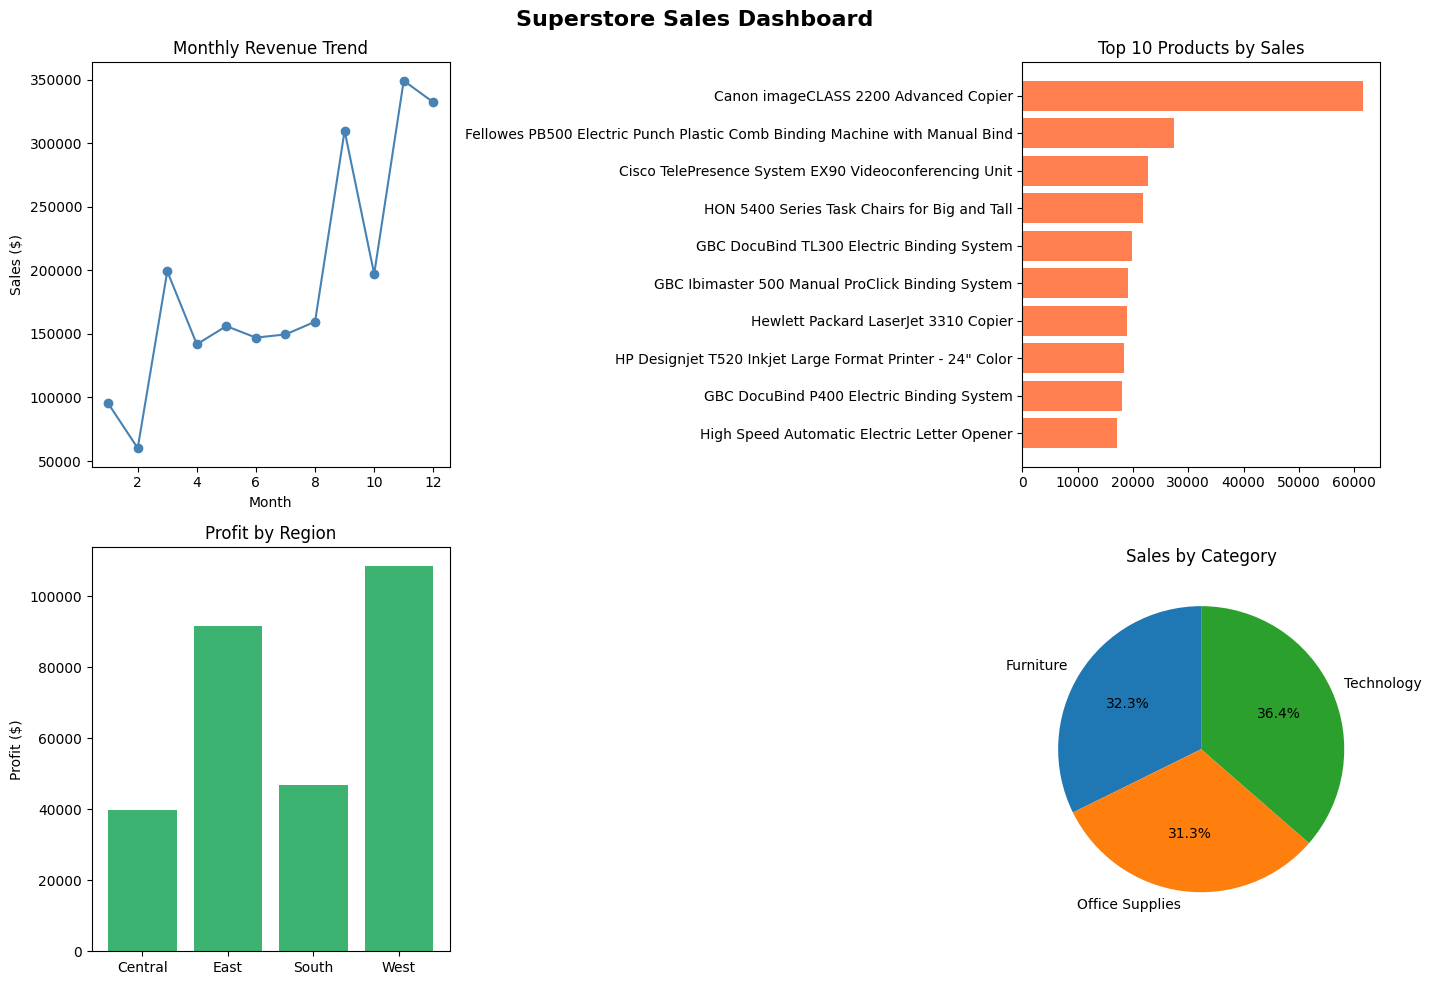

Dashboard saved!


In [31]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Superstore Sales Dashboard', fontsize=16, fontweight='bold')

# Chart 1: Monthly sales trend
monthly_total = df.groupby('month')['sales'].sum()
axes[0,0].plot(monthly_total.index, monthly_total.values, marker='o', color='steelblue')
axes[0,0].set_title('Monthly Revenue Trend')
axes[0,0].set_xlabel('Month')
axes[0,0].set_ylabel('Sales ($)')

# Chart 2: Top 10 products
axes[0,1].barh(top_products['product_name'], top_products['sales'], color='coral')
axes[0,1].set_title('Top 10 Products by Sales')
axes[0,1].invert_yaxis()

# Chart 3: Profit by region
axes[1,0].bar(region_profit['region'], region_profit['profit'], color='mediumseagreen')
axes[1,0].set_title('Profit by Region')
axes[1,0].set_ylabel('Profit ($)')

# Chart 4: Sales by category
category_total = df.groupby('category')['sales'].sum()
axes[1,1].pie(category_total, labels=category_total.index, autopct='%1.1f%%', startangle=90)
axes[1,1].set_title('Sales by Category')

plt.tight_layout()
plt.savefig('dashboard.png', dpi=150)
plt.show()
print("Dashboard saved!")

In [32]:
!pip install mysql-connector-python sqlalchemy pymysql

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.7/21.7 MB 62.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 1.8 MB/s eta 0:00:00
